In [1]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, matthews_corrcoef, cohen_kappa_score, 
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, 
    GlobalAveragePooling1D, Dense, Dropout, Add, MaxPooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.ticker as ticker

In [2]:
# =========================================
# REPRODUCIBILITY & HYPERPARAMETERS
# =========================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

EPOCHS = 100
BATCH_SIZE = 64
LEARNING_RATE = 0.001

In [3]:
# =========================================
# DATASET LOADING (FordA Benchmark)
# =========================================
def load_benchmark_data():
    """Load and normalize the FordA benchmark dataset."""
    train_data = np.loadtxt("FordA_TRAIN.txt")
    test_data = np.loadtxt("FordA_TEST.txt")

    y_train = np.where(train_data[:, 0] == -1, 0, 1)
    X_train = train_data[:, 1:]
    y_test = np.where(test_data[:, 0] == -1, 0, 1)
    X_test = test_data[:, 1:]

    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)[..., np.newaxis]
    X_val = scaler.transform(X_val)[..., np.newaxis]
    X_test = scaler.transform(X_test)[..., np.newaxis]
    
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = load_benchmark_data()

In [4]:
# =========================================
# CUSTOM LOSS FUNCTIONS
# =========================================
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        p_t = (y_true * y_pred + (1 - y_true) * (1 - y_pred))
        alpha_factor = (y_true * alpha + (1 - y_true) * (1 - alpha))
        modulating_factor = tf.pow((1.0 - p_t), gamma)
        return tf.reduce_mean(alpha_factor * modulating_factor * bce)
    return loss

LOSS_FUNCTIONS = {
    "Binary_Crossentropy": tf.keras.losses.BinaryCrossentropy(),
    "BCE_with_Label_Smoothing": tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    "Mean_Squared_Error": tf.keras.losses.MeanSquaredError(),
    "Focal_Loss": focal_loss(),
    "Log_Cosh_Loss": tf.keras.losses.LogCosh()
}

In [5]:
# =========================================
# MODEL ARCHITECTURE (Deep Residual CNN)
# =========================================
def residual_block(x, filters):
    shortcut = x
    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(shortcut)
    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

def build_resnet_model():
    inputs = Input(shape=(X_train.shape[1], 1))
    x = Conv1D(64, 7, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = residual_block(x, 64)
    x = MaxPooling1D(2)(x)
    x = residual_block(x, 128)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

In [6]:
# =========================================
# EXPERIMENT EXECUTION
# =========================================
history_records = {}
comparison_metrics = []

print(f"Starting experiments for {len(LOSS_FUNCTIONS)} loss functions...")

for name, loss_fn in LOSS_FUNCTIONS.items():
    print(f"Training Model with: {name}...", end=" ", flush=True)
    
    model = build_resnet_model()
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss=loss_fn, metrics=['accuracy'])
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0 
    )
    
    history_records[name] = history.history['loss']
    
    # Final Evaluation on Test Set
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    
    comparison_metrics.append({
        "Loss Function": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "Cohen_Kappa": cohen_kappa_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })
    print("Training Complete.")

Starting experiments for 5 loss functions...
Training Model with: Binary_Crossentropy... WARNING:tensorflow:TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
Training Complete.
Training Model with: BCE_with_Label_Smoothing... Training Complete.
Training Model with: Mean_Squared_Error... Training Complete.
Training Model with: Focal_Loss... Training Complete.
Training Model with: Log_Cosh_Loss... Training Complete.


In [7]:
# =========================================
# ACADEMIC REPORTING & VISUALIZATION
# =========================================

# 1. Performance Comparison Table
results_df = pd.DataFrame(comparison_metrics)
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print("\n" + "="*95)
print("              SUMMARY OF PERFORMANCE METRICS ACROSS LOSS FUNCTIONS")
print("="*95)
print(results_df.to_string(index=False))
print("="*95)


              SUMMARY OF PERFORMANCE METRICS ACROSS LOSS FUNCTIONS
           Loss Function  Accuracy  Precision   Recall  F1-Score      MCC  Cohen_Kappa  ROC_AUC
           Log_Cosh_Loss  0.932576   0.911677 0.953052  0.931905 0.866039     0.865204 0.978398
      Mean_Squared_Error  0.928788   0.940226 0.910798  0.925278 0.857689     0.857294 0.979038
              Focal_Loss  0.920455   0.881429 0.965571  0.921583 0.844817     0.841215 0.976328
     Binary_Crossentropy  0.917424   0.873239 0.970266  0.919199 0.840097     0.835246 0.976719
BCE_with_Label_Smoothing  0.909848   0.875723 0.948357  0.910594 0.822623     0.819975 0.969692



Generating individual convergence plots for thesis documentation...


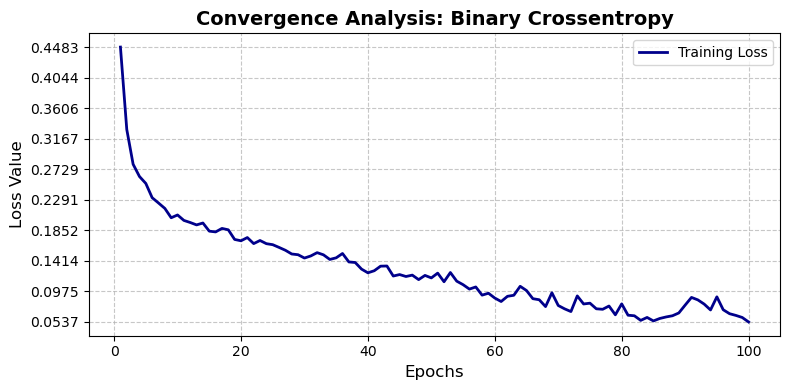

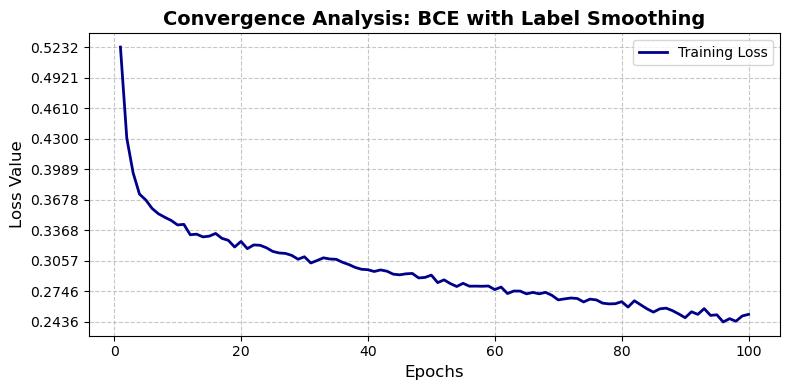

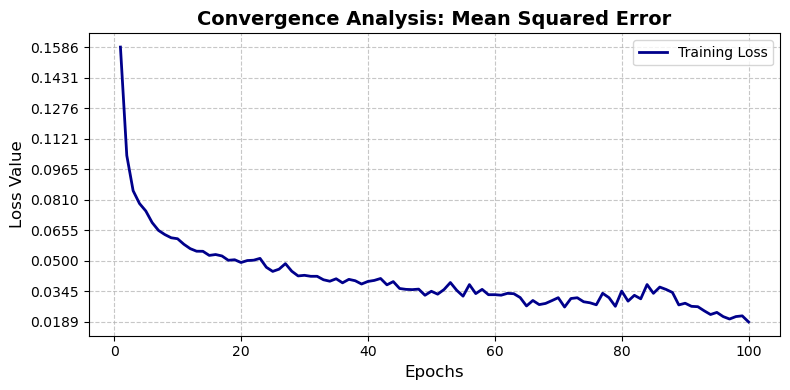

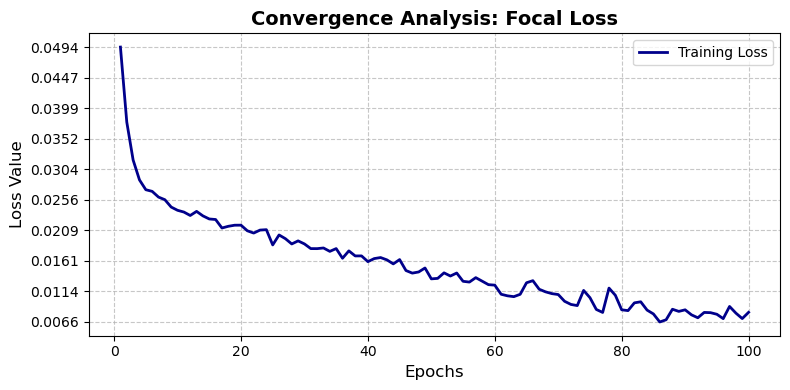

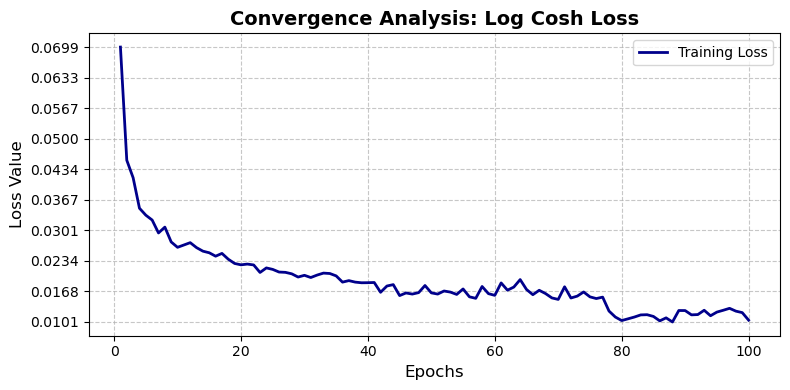

In [8]:
# 2. Individual Convergence Plots
def plot_individual_convergence(name, values):
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, EPOCHS + 1), values, color='darkblue', linewidth=2, label='Training Loss')
    
    plt.title(f'Convergence Analysis: {name.replace("_", " ")}', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    
    # Detailed numbering for y-axis
    ax = plt.gca()
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))
    plt.grid(True, which="both", linestyle='--', alpha=0.7)
    
    # Increasing tick density
    y_min, y_max = min(values), max(values)
    plt.yticks(np.linspace(y_min, y_max, 10)) 
    
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\nGenerating individual convergence plots for thesis documentation...")
for name, loss_values in history_records.items():
    plot_individual_convergence(name, loss_values)